In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv(r'c:\aispry\data\processed\training_dataset.csv')
df.head()

,Age,Gender,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status,Degree_B.Tech,Degree_BCA,Degree_MCA,Branch_Civil,Branch_ECE,Branch_IT,Branch_ME
0,18.0,1,7.22,1,5,9,7,78,6,3,0,1,True,False,False,False,False,True,False
1,23.0,0,7.41,0,4,5,4,53,6,1,0,0,False,True,False,True,False,False,False
2,20.0,0,9.32,1,4,5,7,91,5,2,0,1,False,False,False,False,False,True,False
3,23.0,0,8.14,1,5,8,3,70,5,2,0,0,False,True,False,False,False,False,False
4,20.0,0,7.44,2,4,5,2,74,6,2,0,0,True,False,False,True,False,False,False


In [4]:
X = df.drop("Placement_Status", axis=1)
y = df["Placement_Status"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## VIF

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = X.apply(pd.to_numeric)
X = X.astype(float)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)
print(vif_data)

                 Feature         VIF
2                   CGPA  185.653916
4               Projects  175.627197
5          Coding_Skills   90.689286
0                    Age   75.482578
7    Aptitude_Test_Score   61.581699
9         Certifications   43.816499
8     Soft_Skills_Rating   19.469691
6   Communication_Skills   13.624886
3            Internships    2.558999
14          Branch_Civil    2.510101
10              Backlogs    2.410046
17             Branch_ME    2.315120
1                 Gender    2.219255
15            Branch_ECE    2.175458
16             Branch_IT    2.003235
13            Degree_MCA    1.980268
11         Degree_B.Tech    1.975575
12            Degree_BCA    1.958862


In [8]:
X.drop(
    columns=[
        "Projects",
        "Certifications",
        "Aptitude_Test_Score"
    ],
    inplace=True
)
X = X.apply(pd.to_numeric)
X = X.astype(float)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)
print(vif_data)

                 Feature        VIF
2                   CGPA  75.696463
0                    Age  73.551363
6     Soft_Skills_Rating  19.442541
4          Coding_Skills  18.780906
5   Communication_Skills  13.605774
3            Internships   2.558572
11          Branch_Civil   2.509651
7               Backlogs   2.407359
14             Branch_ME   2.314657
1                 Gender   2.219040
12            Branch_ECE   2.175166
13             Branch_IT   2.002833
10            Degree_MCA   1.979852
8          Degree_B.Tech   1.974877
9             Degree_BCA   1.958009


In [9]:
X.drop(columns=["Soft_Skills_Rating"],inplace=True)

In [21]:
# Remove high VIF features

X_train = X_train.drop(
    columns=[
        "Projects",
        "Certifications",
        "Aptitude_Test_Score",
        "Soft_Skills_Rating"
    ]
)

# Remove high VIF features

X_test = X_test.drop(
    columns=[
        "Projects",
        "Certifications",
        "Aptitude_Test_Score",
        "Soft_Skills_Rating"
    ]
)

## Model 1-Logistic Regression

In [22]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
log_accuracy = accuracy_score(y_test, y_pred_log)
print(f"\nAccuracy  : {log_accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))


Accuracy  : 0.8684

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.90      0.90      5486
           1       0.82      0.81      0.82      3076

    accuracy                           0.87      8562
   macro avg       0.86      0.86      0.86      8562
weighted avg       0.87      0.87      0.87      8562



## Model 2-Random Forest

In [23]:
rf_model = rf_model = RandomForestClassifier(n_estimators=100,max_depth=5,min_samples_split=10,min_samples_leaf=5,random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"\nAccuracy  : {rf_accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Accuracy  : 0.9841

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      5486
           1       0.96      1.00      0.98      3076

    accuracy                           0.98      8562
   macro avg       0.98      0.99      0.98      8562
weighted avg       0.98      0.98      0.98      8562



## Model 3-XGBoost

In [24]:
xgb_model = xgb_model = XGBClassifier(max_depth=4,learning_rate=0.1,n_estimators=100,subsample=0.8,colsample_bytree=0.8,eval_metric="logloss",random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"\nAccuracy  : {xgb_accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))


Accuracy  : 0.9841

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      5486
           1       0.96      1.00      0.98      3076

    accuracy                           0.98      8562
   macro avg       0.98      0.99      0.98      8562
weighted avg       0.98      0.98      0.98      8562



In [25]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

print(comparison_df)

                 Model  Accuracy
0  Logistic Regression  0.868372
1        Random Forest  0.984116
2              XGBoost  0.984116


In [26]:
import os

os.makedirs("models", exist_ok=True)

joblib.dump(xgb_model, "models/best_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!



AUC Score: 0.9951955077044441


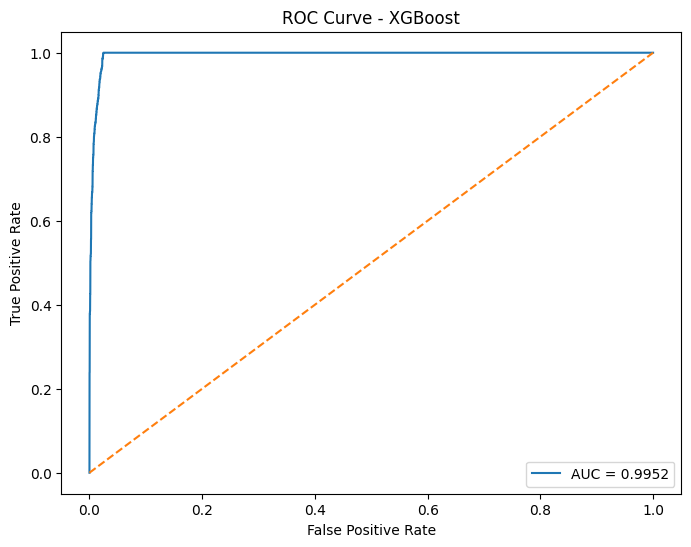

In [27]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_prob = xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("\nAUC Score:", roc_auc)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.show()


Feature Importance:

                 Feature  Importance
5   Communication_Skills    0.315093
4          Coding_Skills    0.298206
6               Backlogs    0.203306
2                   CGPA    0.134699
3            Internships    0.028262
10          Branch_Civil    0.011485
9             Degree_MCA    0.003213
0                    Age    0.001714
1                 Gender    0.001614
11            Branch_ECE    0.001064
13             Branch_ME    0.000878
8             Degree_BCA    0.000466
7          Degree_B.Tech    0.000000
12             Branch_IT    0.000000


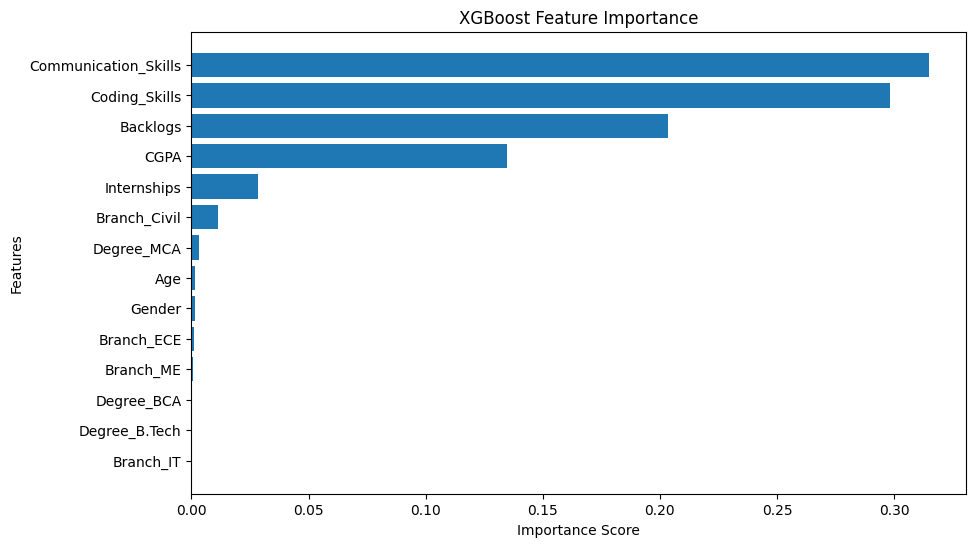

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})


importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:\n")
print(importance_df)


plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [29]:
importance = xgb_model.feature_importances_

feature_names = X_train.columns

print("Number of Features:", len(feature_names))
print("Importance Length:", len(importance))

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

Number of Features: 14
Importance Length: 14
